Notebook for composite Bayesian Optimization on Tilt and Thickness<br>
Written by Dasol Yoon and Poompol Buathong<br>
Last edited on Jan 6, 2025

Different number of patches

In [1]:
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

/opt/miniconda3/envs/BOttV02/bin/python
3.13.1 | packaged by conda-forge | (main, Dec  5 2024, 21:09:18) [Clang 18.1.8 ]
sys.version_info(major=3, minor=13, micro=1, releaselevel='final', serial=0)


In [2]:
%matplotlib inline

In [3]:
import torch
import random
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_model
from botorch.acquisition.objective import GenericMCObjective
from botorch.models.gp_regression import FixedNoiseGP, SingleTaskGP
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf

import math
import numpy as np
import matplotlib.pyplot as plt

# use a GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double
print(device)

cpu


In [4]:
tkwargs = {"dtype":torch.double}#,
           #"device": torch.device(device)}

In [5]:
tkwargs

{'dtype': torch.float64}

In [6]:
import scipy.ndimage
import glob
from datetime import datetime
import warnings

In [7]:
#change the file path to where the dataset is/will be stored

#fpath = 'D:/Lab/Experiments/20231100-TiltML/data/data/1/simulation/'
fpath = '/Users/dash/Documents/Cornell/BOtt/simulation/'

In [150]:
def load(x):
    #----variables----
    #x: [[thickness [angstrom], tilt]]
    #returns pre-simulated PACBED image.
    thickness=x[0,0]
    tilt = x[0,1]   
    
    tag = '/{:04d}'.format(int(thickness))
    imgPath = glob.glob(fpath+'Tilt_{}_Azimuth_0_Conv_Angle_25.0/'.format(int(tilt))
                        +tag[:4]+'*.tif')[0] #1st in list
    try: #load PACBED from the directory
        pacbed = plt.imread(imgPath)
        pacbed = pacbed.astype(np.float64) #added 20241112. bad simulation. crop zeroes.
    except: #handle exceptions
        print('no such file: ' +imgPath)

    #pacbed_sqrt = np.sqrt(pacbed) #added 20241017
    #pacbed_norm = pacbed_sqrt/np.mean(pacbed_sqrt) #added 20241017; "standardize" the data...? Isn't it redundant with the normalization?
    pacbed_norm = (pacbed-np.min(pacbed))/(np.max(pacbed)-np.min(pacbed)) #normalize 0-1
    #pacbed_smol = scipy.ndimage.zoom(pacbed_norm.astype(np.float64),20/pacbed_norm.shape[0],order=1) #Nov12: comment out
    #pacbed_norm = (pacbed_smol-np.min(pacbed_smol))/(np.max(pacbed_smol)-np.min(pacbed_smol)) #normalize 0-1 #Nov12: comment out
    

    #unicode for angstrom
    #print('thickness: {} \u212B  || shape: {} || filename: '.format(x, pacbed_norm.shape)+imgPath[90:])
    
    return torch.Tensor(pacbed_norm)#.reshape(-1) #PB: change to tensor

In [151]:
y_raw_noCrop = load(x_real)

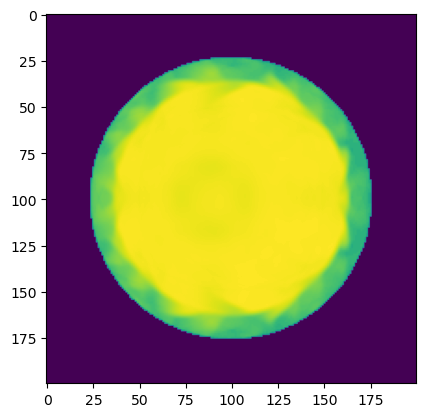

In [153]:
plt.figure()
plt.imshow(y_raw_noCrop**0.1)

In [8]:
def load(x):
    #----variables----
    #x: [[thickness [angstrom], tilt]]
    #returns pre-simulated PACBED image.
    thickness=x[0,0]
    tilt = x[0,1]   
    
    tag = '/{:04d}'.format(int(thickness))
    imgPath = glob.glob(fpath+'Tilt_{}_Azimuth_0_Conv_Angle_25.0/'.format(int(tilt))
                        +tag[:4]+'*.tif')[0] #1st in list
    try: #load PACBED from the directory
        pacbed = plt.imread(imgPath)
        pacbed = pacbed[25:-25,25:-25].astype(np.float64) #added 20241112. bad simulation. crop zeroes.
    except: #handle exceptions
        print('no such file: ' +imgPath)

    #pacbed_sqrt = np.sqrt(pacbed) #added 20241017
    #pacbed_norm = pacbed_sqrt/np.mean(pacbed_sqrt) #added 20241017; "standardize" the data...? Isn't it redundant with the normalization?
    pacbed_norm = (pacbed-np.min(pacbed))/(np.max(pacbed)-np.min(pacbed)) #normalize 0-1
    #pacbed_smol = scipy.ndimage.zoom(pacbed_norm.astype(np.float64),20/pacbed_norm.shape[0],order=1) #Nov12: comment out
    #pacbed_norm = (pacbed_smol-np.min(pacbed_smol))/(np.max(pacbed_smol)-np.min(pacbed_smol)) #normalize 0-1 #Nov12: comment out
    

    #unicode for angstrom
    #print('thickness: {} \u212B  || shape: {} || filename: '.format(x, pacbed_norm.shape)+imgPath[90:])
    
    return torch.Tensor(pacbed_norm)#.reshape(-1) #PB: change to tensor

In [9]:
# This is the correct value of the parameter
x_real = np.array([[250,4]])

# Get the PACBED at the thickness of x_real
y_raw = load(x_real) #[simulate(x_val) for x_val in x_obs]

# Upper and lower bounds for our search
lower = 10
upper = 500

In [57]:
temp_y = load( np.array( [[410,1]]) )

#### testing

In [16]:
y_raw[20:-20,20:-20].shape

torch.Size([110, 110])

In [19]:
110**2

12100

In [20]:
150**2-110**2

10400

In [18]:
110**2/(150**2-110**2)

1.1634615384615385

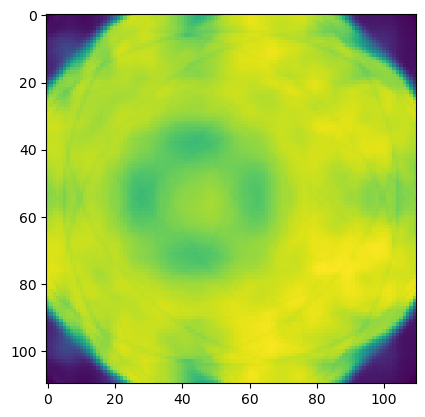

In [15]:
plt.figure()
plt.imshow(y_raw[20:-20,20:-20])

In [23]:
mask = np.zeros((150,150)).astype(bool)
mask[20:-20,20:-20] = True

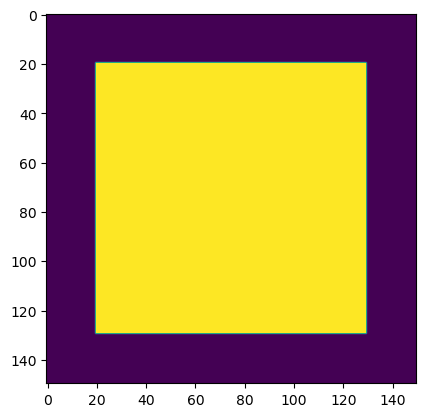

In [27]:
plt.imshow(mask)

In [30]:
len(y_raw[~mask])

10400

#### back to the code

In [10]:
def twoVertTiles(y_raw):
    arr = torch.Tensor([]);
    arr = torch.cat((arr, torch.mean(y_raw[:,:75]).unsqueeze(-1) *1e1), dim=-1)
    arr = torch.cat((arr, torch.mean(y_raw[:,75:]).unsqueeze(-1) *1e1), dim=-1)
    return arr

In [11]:
def domainKnowledgeTile(y_raw):
    #create a mask to divide the image into central and peripheral regions
    mask = np.zeros((150,150)).astype(bool)
    mask[20:-20,20:-20] = True #central region of the image
    
    arr = torch.Tensor([]);
    arr = torch.cat((arr, torch.mean(y_raw[mask]).unsqueeze(-1) *1e1), dim=-1)
    arr = torch.cat((arr, torch.mean(y_raw[~mask]).unsqueeze(-1) *1e1), dim=-1)
    return arr

In [24]:
#TODO: use thinner one for test case
#PB changed to tensor
#TODO: Currently hard coded for the patch size. Need to modify later
def squareTiles(y_raw, **kwargs):
    numTiles= kwargs.get('numTiles',1) #default numTiles value
    arr = torch.Tensor([]);
    pixPerTile = y_raw.shape[0]//numTiles
    for i in range(numTiles):
        for j in range(numTiles):
            tile = torch.mean(y_raw[...,pixPerTile*i:pixPerTile*(i+1),...,pixPerTile*j:pixPerTile*(j+1)]).unsqueeze(-1)
            arr = torch.cat((arr,tile*1e1),dim=-1)
    return arr

In [16]:
def pixelSSE(y_cand_raw,y_ref_raw):
    err = y_cand_raw-y_ref_raw # #one image y_obs: image I want to measure
    return err.pow(2).sum().unsqueeze(-1) #np.power(err,2).sum().unsqueeze(-1) 

In [17]:
def tileSSE(y_cand_tiles,y_ref_tiles): #patches of y and RSS in 10 variables
    return (y_cand_tiles-y_ref_tiles).pow(2).sum().unsqueeze(-1)

In [20]:
def computeY(y_cand_raw,y_ref_raw, method, **kwargs):
    y_cand_tiles = method(y_cand_raw,**kwargs)
    y_ref_tiles = method(y_ref_raw,**kwargs)
    tileTerm = tileSSE(y_cand_tiles,y_ref_tiles)
    pixelTerm = pixelSSE(y_cand_raw, y_ref_raw)
    return torch.cat((y_cand_tiles,pixelTerm-tileTerm),dim=-1).unsqueeze(0).to(**tkwargs) #y_pred

##### testing

In [41]:
tempTiles = domainKnowledgeTile(y_raw)  # compute reference values for patches

In [42]:
tempTiles

tensor([8.1160, 1.4350])

In [25]:
computeY(y_raw, y_raw,squareTiles,numTiles=1)

tensor([[5.0279, 0.0000]], dtype=torch.float64)

In [26]:
tempTerm = computeY(y_raw, y_raw,twoVertTiles)  # compute reference values

In [27]:
tempTerm

tensor([[4.9785, 5.0773, 0.0000]], dtype=torch.float64)

In [62]:
computeY(y_raw,y_raw,twoVertTiles)

tensor([[4.9785, 5.0773, 0.0000]], dtype=torch.float64)

In [61]:
computeY(temp_y,y_raw,twoVertTiles)

tensor([[  4.4854,   4.6115, 150.5838]], dtype=torch.float64)

In [51]:
def tempFunc(y_pred,y_ref): #TODO: using pixelSSE(y_pred_raw) may enhance the speed a bit?
    return -((y_pred[...,:-1]-y_ref[...,:-1]).pow(2).sum()+y_pred[...,-1]).unsqueeze(-1)
    # return - (np.power( y_pred[:9]-y_obsC[:9], 2).sum() + y_pred[9] ) #pixelTerm - patchTerm #question: isn't it just the pixelTerm?

In [63]:
tempFunc(computeY(temp_y,y_raw,twoVertTiles),computeY(y_raw,y_raw,twoVertTiles))

tensor([[-151.0439]], dtype=torch.float64)

In [64]:
tempFunc(computeY(y_raw,y_raw,twoVertTiles),computeY(temp_y,y_raw,twoVertTiles))

tensor([[-0.4601]], dtype=torch.float64)

In [65]:
pixelSSE(temp_y,y_raw)

tensor([151.0439])

In [20]:
def computeObjectiveC(y_pred): #TODO: using pixelSSE(y_pred_raw) may enhance the speed a bit?
    return -((y_pred[...,:-1]-y_obsC[...,:-1]).pow(2).sum()+y_pred[...,-1]).unsqueeze(-1)
    # patchTerm +pixelTerm-patchTerm

In [80]:
def classicalObj(x):
    return - pixelSSE(load(x))

### todo: plot
NOTE: It doesn't make sense to plot the `computeObjectiveC` because it's just getting the pixel SSE.

In [ ]:
computeY(y_raw, y_raw,squareTiles,numTiles=1)

In [31]:
temp={}

In [32]:
computeY(y_raw, y_raw,squareTiles,**temp)

tensor([[5.0279, 0.0000]], dtype=torch.float64)

todo: for thickness and tilt

In [42]:
def exploreDomain_thickness(method,y_ref_raw,**kwargs):
    result = np.array([])
    y_tru_tiles = method(y_ref_raw,**kwargs)
    for i in range(10,1000,10): #start stop step
        temp_y = load( np.array([[i,4]]) )
        y_can_tiles = method(temp_y,**kwargs)
        
        result = np.append(result, tileSSE( y_can_tiles,y_tru_tiles ) )
    obj_real = tileSSE(y_tru_tiles,y_tru_tiles)
    return result, obj_real

In [46]:
def exploreDomain_tilt(method,y_ref_raw,**kwargs):
    result = np.array([])
    y_tru_tiles = method(y_ref_raw,**kwargs)
    for i in range(0,10,1): #start stop step
        temp_y = load( np.array([[250,i]]) )
        y_can_tiles = method(temp_y,**kwargs)
        
        result = np.append(result, tileSSE( y_can_tiles,y_tru_tiles ) )
    obj_real = tileSSE(y_tru_tiles,y_tru_tiles)
    return result, obj_real

In [127]:
def exploreDomain_grid(method,y_ref_raw,**kwargs):
    result = np.array([])
    y_tru_tiles = method(y_ref_raw,**kwargs)
    for i in range(10,1000,10): #start stop step
        for j in range(0,10,1):
            temp_y = load( np.array([[i,j]]) )
            y_can_tiles = method(temp_y,**kwargs)
            
            result = np.append(result, tileSSE( y_can_tiles,y_tru_tiles ) )
    obj_real = tileSSE(y_tru_tiles,y_tru_tiles)
    return result.reshape(-1,j+1), obj_real

In [162]:
torch.sum(temp_y)

tensor(9030.2275)

In [163]:
arr_temp = np.array([])
arr_temp2 = np.array([])
for i in range(10,1000,10): #start stop step
    for j in range(0,10,1):
        temp_y = load( np.array([[i,j]]) )
        arr_temp2 = np.append( arr_temp2, torch.sum(temp_y))
        arr_temp = np.append( arr_temp, squareTiles(temp_y,numTiles=1))
arr_temp = arr_temp.reshape(99,10)
arr_temp2 = arr_temp2.reshape(99,10)

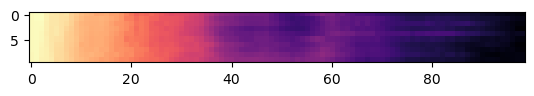

In [164]:
plt.imshow(arr_temp2.T,cmap='magma')

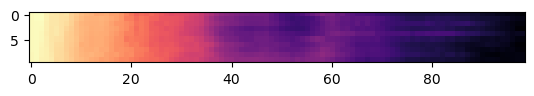

In [157]:
plt.imshow(arr_temp.T,cmap='magma')

In [133]:
arr_pix = np.array([])
for i in range(10,1000,10): #start stop step
    for j in range(0,10,1):
        temp_y = load( np.array([[i,j]]) )
        arr_pix = np.append( arr_pix, pixelSSE(temp_y,y_raw))
arr_pix = arr_pix.reshape(99,10)

In [95]:
def plotGrid(ax,arr,obj_true,scale=0.5,tickLab=None):
    ax.imshow(arr.T**scale, cmap='magma_r',interpolation=None)
    ax.plot(obj_true[0,0]/10-1,obj_true[0,1],'go',markersize=1)
    ax.set_xlabel('thickness (angstrom)'); ax.set_ylabel('tilt')
    if tickLab is not None:
        ax.set(xticks=np.linspace(0, arr.shape[0]-1,len(tickLab)),xticklabels=tickLab.astype(int))

In [128]:
arr_twoVert,val_twoVert = exploreDomain_grid(twoVertTiles,y_raw)

In [129]:
arr_domain,val_domain = exploreDomain_grid(domainKnowledgeTile,y_raw)

In [130]:
arr_sqt1,val_sqt1 = exploreDomain_grid(squareTiles,y_raw,numTiles=1)

In [131]:
arr_sqt3,val_sqt3 = exploreDomain_grid(squareTiles,y_raw,numTiles=3)

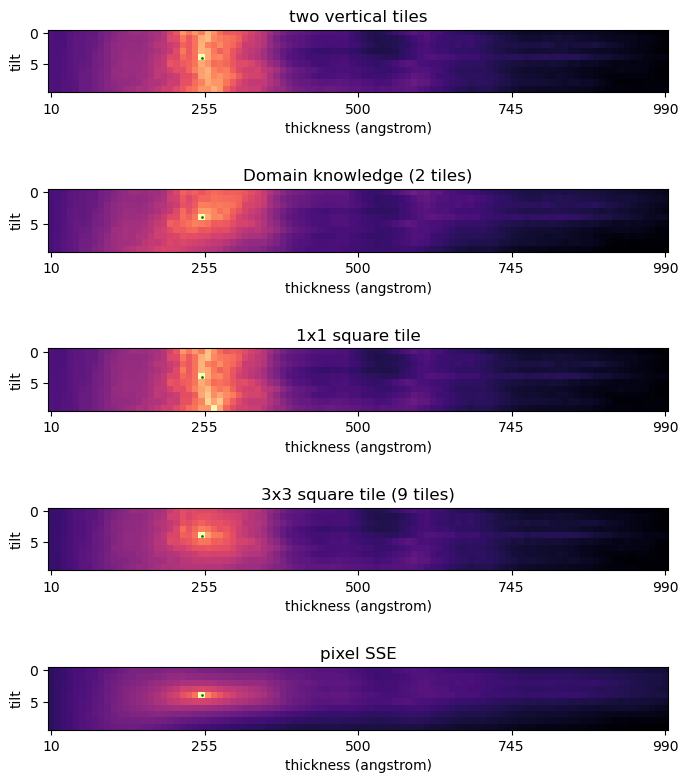

In [134]:
fig,axl = plt.subplots(5,1,figsize=(8,10))

for a,arr,text in zip(axl, [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix], 
                   ['two vertical tiles','Domain knowledge (2 tiles)','1x1 square tile',
                    '3x3 square tile (9 tiles)','pixel SSE'] ):
    plotGrid(a, arr,x_real,scale=0.2,tickLab=np.linspace(10,990,5))
    a.set_title(text)

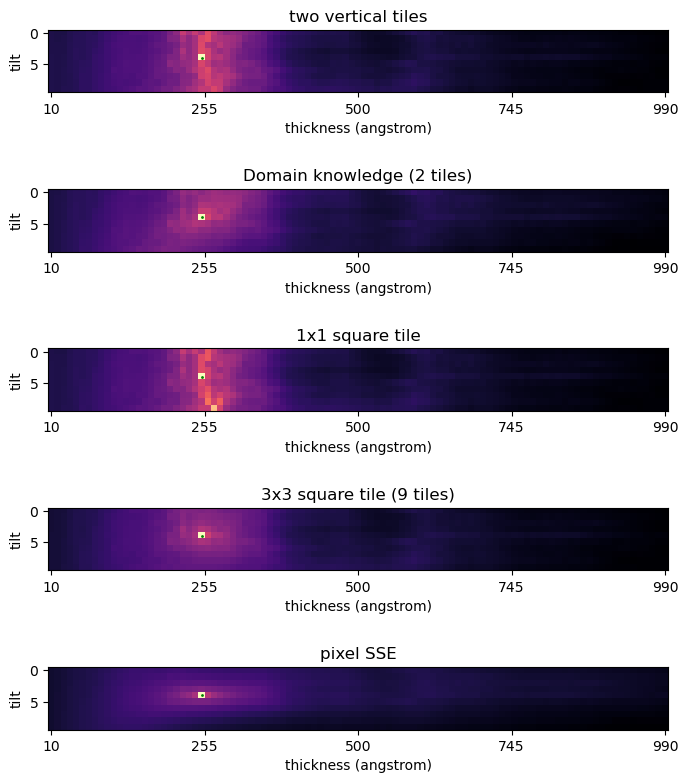

In [123]:
fig,axl = plt.subplots(5,1,figsize=(8,10))

for a,arr,text in zip(axl, [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix], 
                   ['two vertical tiles','Domain knowledge (2 tiles)','1x1 square tile',
                    '3x3 square tile (9 tiles)','pixel SSE'] ):
    plotGrid(a, arr.reshape(99,10),x_real,scale=0.1,tickLab=np.linspace(10,990,5))
    a.set_title(text)

In [ ]:
arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix

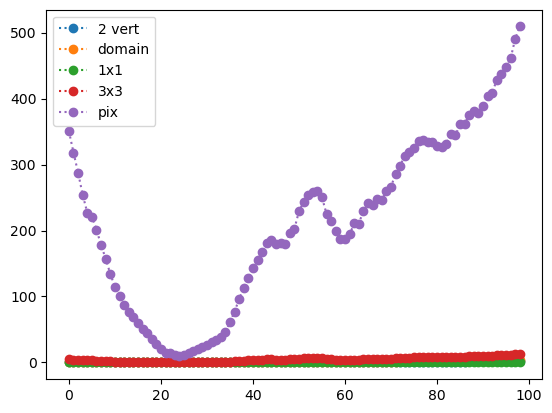

In [138]:
plt.figure()
for arr,text in zip( [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix],
                    ['2 vert','domain','1x1','3x3','pix'] ): 
    plt.plot(arr[:,3],'o:',label=text)
plt.legend()

Text(0, 0.5, 'tileSSE (normalized)')

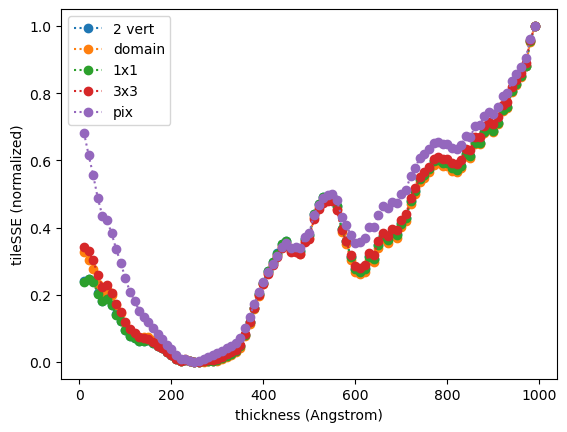

In [142]:
plt.figure()
for arr,text in zip( [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix],
                    ['2 vert','domain','1x1','3x3','pix'] ): 
    plt.plot(range(10,1000,10),normalize(arr[:,3]),'o:',label=text)
plt.legend()
plt.xlabel('thickness (Angstrom)')
plt.ylabel('tileSSE (normalized)')

Text(0, 0.5, 'tileSSE (normalized)')

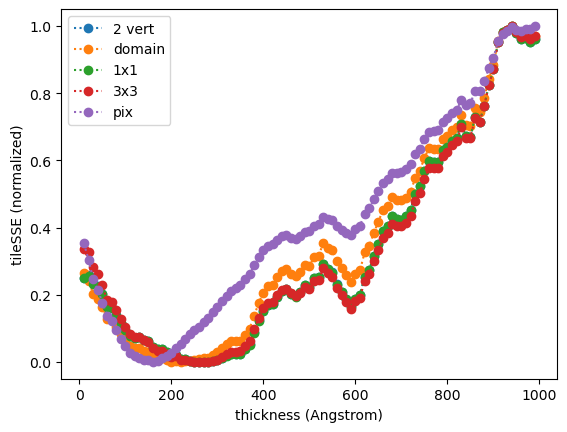

In [143]:
plt.figure()
for arr,text in zip( [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix],
                    ['2 vert','domain','1x1','3x3','pix'] ): 
    plt.plot(range(10,1000,10),normalize(arr[:,8]),'o:',label=text)
plt.legend()
plt.xlabel('thickness (Angstrom)')
plt.ylabel('tileSSE (normalized)')

Text(0, 0.5, 'tileSSE (normalized)')

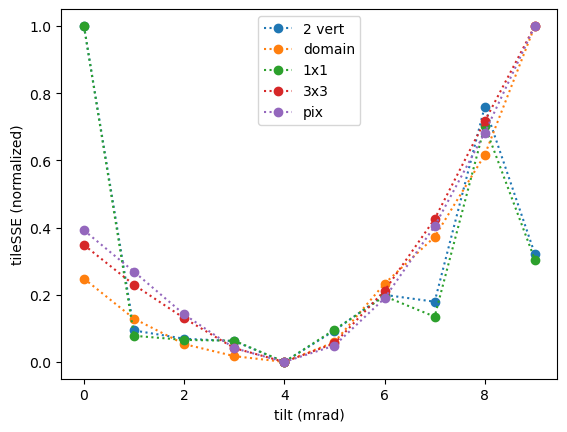

In [145]:
plt.figure()
for arr,text in zip( [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix],
                    ['2 vert','domain','1x1','3x3','pix'] ): 
    plt.plot(normalize(arr[24,:]),'o:',label=text)
plt.legend()
plt.xlabel('tilt (mrad)')
plt.ylabel('tileSSE (normalized)')

Text(0, 0.5, 'tileSSE (normalized)')

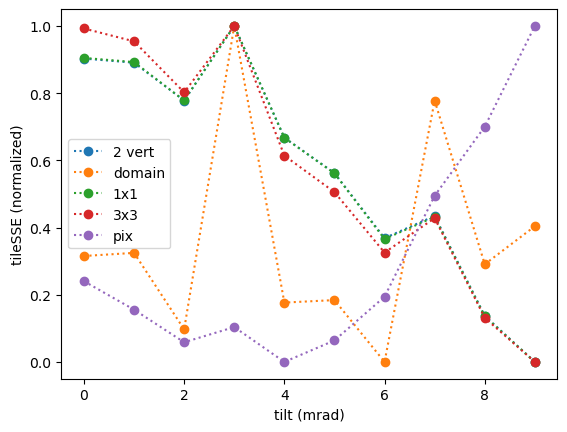

In [148]:
plt.figure()
for arr,text in zip( [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix],
                    ['2 vert','domain','1x1','3x3','pix'] ): 
    plt.plot(normalize(arr[50,:]),'o:',label=text)
plt.legend()
plt.xlabel('tilt (mrad)')
plt.ylabel('tileSSE (normalized)')

Text(0, 0.5, 'tileSSE (normalized)')

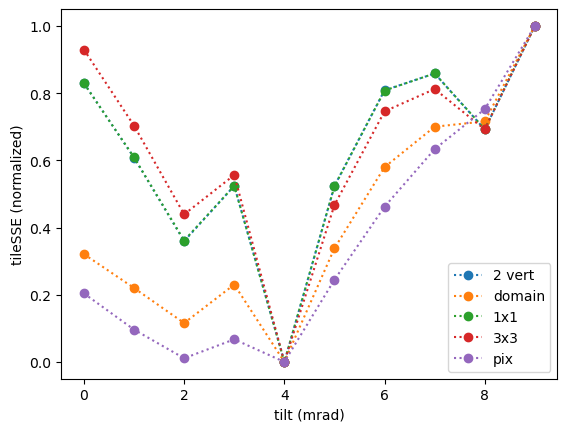

In [149]:
plt.figure()
for arr,text in zip( [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix],
                    ['2 vert','domain','1x1','3x3','pix'] ): 
    plt.plot(normalize(arr[80,:]),'o:',label=text)
plt.legend()
plt.xlabel('tilt (mrad)')
plt.ylabel('tileSSE (normalized)')

Text(0, 0.5, 'tileSSE (normalized)')

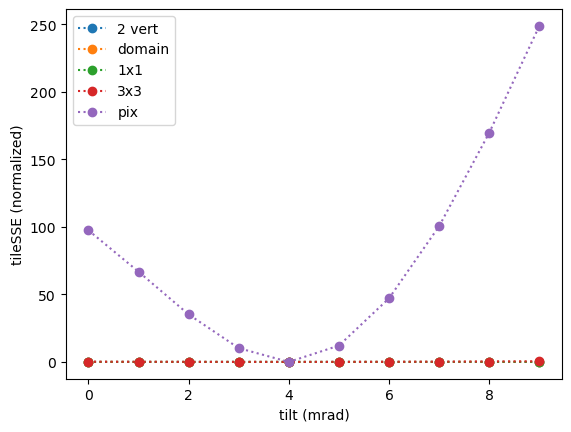

In [146]:
plt.figure()
for arr,text in zip( [arr_twoVert,arr_domain,arr_sqt1,arr_sqt3,arr_pix],
                    ['2 vert','domain','1x1','3x3','pix'] ): 
    plt.plot(arr[24,:],'o:',label=text)
plt.legend()
plt.xlabel('tilt (mrad)')
plt.ylabel('tileSSE (normalized)')

In [139]:
def normalize(var):
    return (var - np.min(var))/(np.max(var)-np.min(var))

Text(0.5, 1.0, 'two vertical tiles')

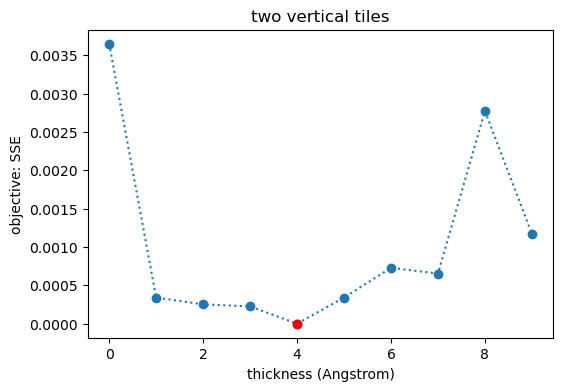

In [50]:
#twoVertTiles
fig,ax = plt.subplots(figsize=(6,4))
plt.plot(range(0,10,1), tempArr, 'o:')
plt.xlabel('thickness (Angstrom)')
plt.ylabel('objective: SSE')
plt.plot(x_real[0,1],tempVal,'ro')
plt.title('two vertical tiles')

In [33]:
#adjust these
met = twoVertTiles
arr_obj_twoVert = np.array([])
targs = {}

#let these run
temp_y_ref_tiles = met(y_raw)
for i in range(10,1000,10): #start stop step
    temp_y = load( np.array([[i,4]]) )
    y_can_tiles = met(temp_y,**targs)
    y_tru_tiles = met(y_raw,**targs)
    
    arr_obj_twoVert = np.append(arr_obj_twoVert, tileSSE( y_can_tiles,y_tru_tiles ) )
obj_real = tileSSE(y_tru_tiles,y_tru_tiles)

In [ ]:
arr_obj_twoVert
obj_real_twoVert

Text(0.5, 1.0, 'two vertical tiles')

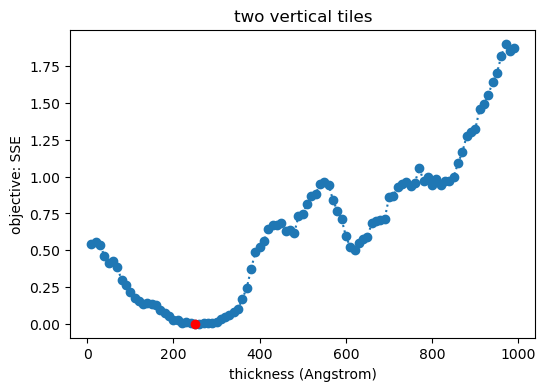

In [44]:
#twoVertTiles
fig,ax = plt.subplots(figsize=(6,4))
plt.plot(range(10,1000,10), tempArr, 'o:')
plt.xlabel('thickness (Angstrom)')
plt.ylabel('objective: SSE')
plt.plot(x_real[0,0],tempVal,'ro')
plt.title('two vertical tiles')

Text(0.5, 1.0, 'numPatches: 3')

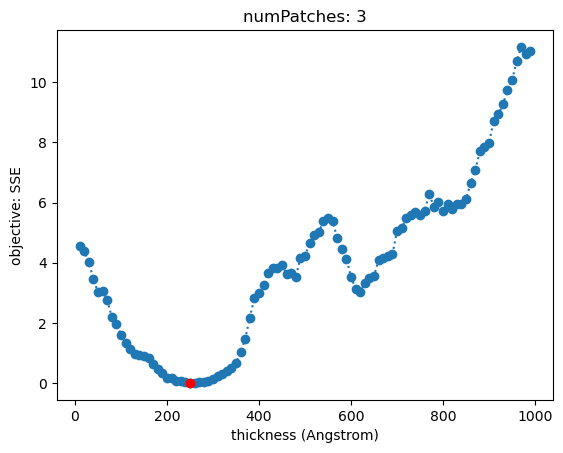

In [24]:
#twoVertTiles
fig,ax = plt.subplots(figsize=(6,4))
plt.plot(range(10,1000,10), arr_obj_twoVert, 'o:')
plt.xlabel('thickness (Angstrom)')
plt.ylabel('objective: SSE')
plt.plot(x_real[0,0],obj_real,'ro')
plt.title('numPatches: {}'.format(numPatches))

In [23]:
arr_obj3

array([4.56975460e+00, 4.39461088e+00, 4.02302265e+00, 3.46507144e+00,
       3.01033831e+00, 3.06901622e+00, 2.76367068e+00, 2.18919826e+00,
       1.96364069e+00, 1.59551823e+00, 1.31435692e+00, 1.14158762e+00,
       9.72493947e-01, 9.40157354e-01, 8.79405618e-01, 8.25013816e-01,
       6.18262708e-01, 4.77560520e-01, 3.44841063e-01, 1.70270920e-01,
       1.57318681e-01, 5.11716679e-02, 6.77638575e-02, 3.05527654e-02,
       0.00000000e+00, 4.01784619e-03, 2.19923332e-02, 2.46031061e-02,
       5.74375466e-02, 1.14868626e-01, 2.32572347e-01, 2.98054188e-01,
       4.08283144e-01, 5.05745173e-01, 6.52940512e-01, 1.04349792e+00,
       1.45837045e+00, 2.17596507e+00, 2.82487082e+00, 3.00676036e+00,
       3.24860811e+00, 3.67188931e+00, 3.83383226e+00, 3.81915283e+00,
       3.91244912e+00, 3.61765528e+00, 3.64465308e+00, 3.52925038e+00,
       4.15206003e+00, 4.23710680e+00, 4.64366245e+00, 4.91890955e+00,
       5.03047037e+00, 5.37817860e+00, 5.48576641e+00, 5.37834358e+00,
      